## Educational Analytics Prediction Platform

### EDA

\Importing Necessary Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

\Loading the Dataset

In [3]:
df_raw = pd.read_csv(r"C:\NG\Educational-Analytics-Platform\data\raw\student_dropout_dataset.csv")
target = "Dropout"

\Target Distribution

In [11]:
def plot_target_distribution(df,target):
    counts = df[target].value_counts()
    pct = df[target].value_counts(normalize=True) *100

    fig,ax = plt.subplots(figsize=(8,5))
    bars = ax.bar(counts.index.astype(str),counts.values,
                  color=sns.color_palette("Set2",len(counts)))

    for bar,count,pct in zip(bars,counts,pct):
        ax.text(bar.get_x() + bar.get_width() /2, bar.get_height(),
                f"{count}\n({pct:.1f}%)",ha="center",va="bottom")
    ax.set_title(f"Target Distibution: {target}")
    ax.set_xlabel(target)
    ax.set_ylabel("count")
    plt.tight_layout()
    plt.show()

    imbalance_ratio = counts.max() / counts.min()
    print(f"Imbalance ratio (majority/minority): {imbalance_ratio:.2f}")
    if imbalance_ratio > 1.5:
        print("Dataset is Imbalanced")
    else:
        print("Dataset is Balanced")

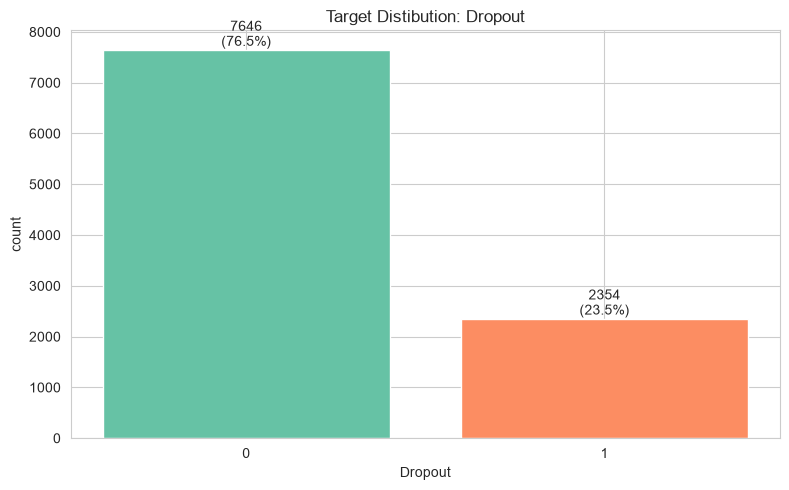

Imbalance ratio (majority/minority): 3.25
Dataset is Imbalanced


In [12]:
plot_target_distribution(df_raw,target)

\Correlation Analysis

In [16]:
def plot_correlation(df,target=None):
    numeric_df = df.select_dtypes(include=np.number)

    if numeric_df.shape[1]<2:
        print("Need atleast 2 numeric columns for correlation")
        return
    corr = numeric_df.corr()

    fig,ax = plt.subplots(figsize=(12,9))
    sns.heatmap(corr,annot=False,cmap="coolwarm",center=0,square=True,linewidths=0.5,ax=ax)
    ax.set_title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()

    if target is not None and target in numeric_df.columns:
        target_corr = corr[target].drop(target).abs().sort_values(ascending=False)
        print(f"Top features correlated with '{target}':")
        for col ,val in target_corr.head(10).items():
            print(f"  {col}: {val:.3f}")

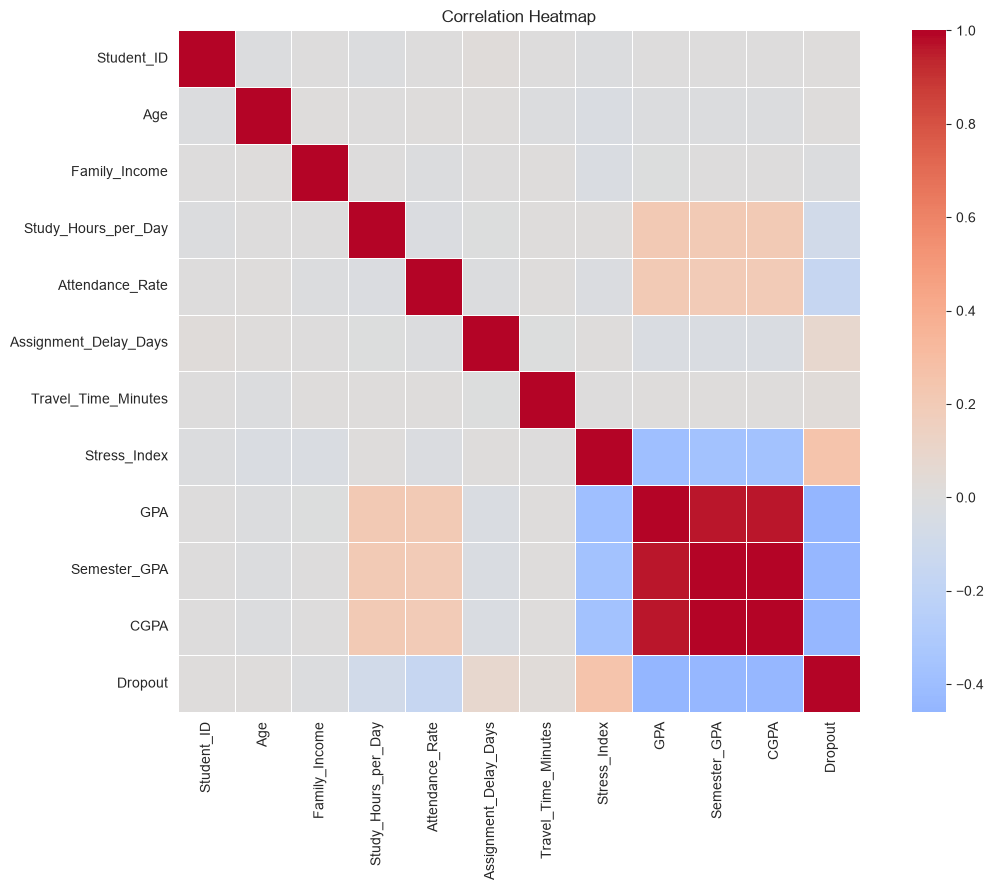

Top features correlated with 'Dropout':
  GPA: 0.460
  Semester_GPA: 0.445
  CGPA: 0.445
  Stress_Index: 0.256
  Attendance_Rate: 0.164
  Study_Hours_per_Day: 0.089
  Assignment_Delay_Days: 0.082
  Travel_Time_Minutes: 0.028
  Family_Income: 0.011
  Age: 0.008


In [17]:
plot_correlation(df_raw,target=target)

\Numeric columns vs target analysis

In [18]:
def plot_numeric_distributions(df, target=None, max_cols=12):
    
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    if target in numeric_cols:
        numeric_cols.remove(target)

    if len(numeric_cols) == 0:
        print("No numeric features to plot.")
        return

    numeric_cols = numeric_cols[:max_cols] 

    n = len(numeric_cols)
    ncols = 3
    nrows = (n + ncols - 1) // ncols 

    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
    axes = axes.flatten()  

    for i, col in enumerate(numeric_cols):
        axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
        skew = df[col].skew()
        axes[i].set_title(f"{col}\n(skew={skew:.2f})")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


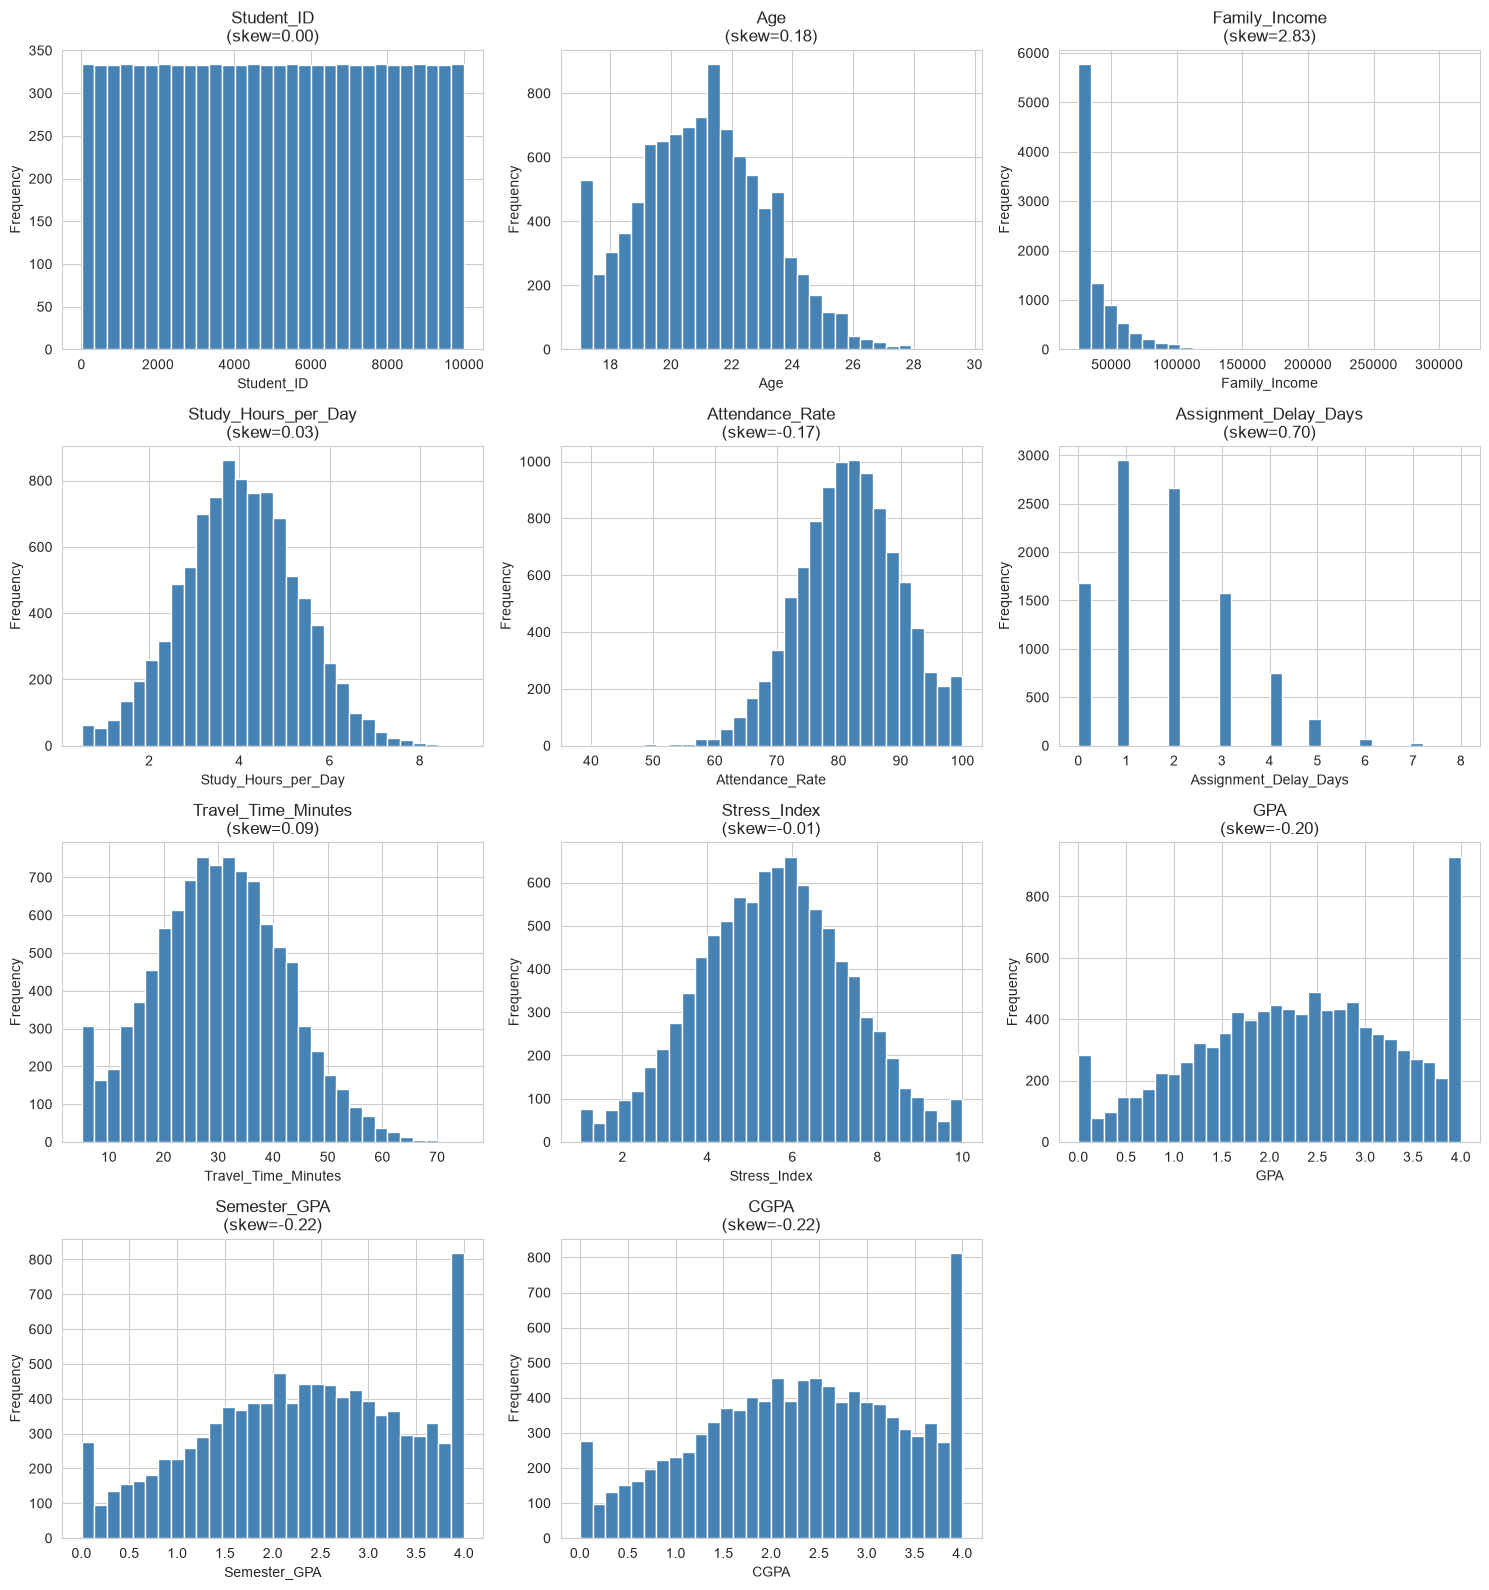

In [20]:
plot_numeric_distributions(df_raw, target=target)